# GridScore — headless reproduction of the data-collection pipeline (ADAPTED PYTHON DEMONSTRATION)

Paper: **"GridScore: a tool for accurate, cross-platform phenotypic data collection and visualization"** — S. Raubach, M. Schreiber, P. D. Shaw, *BMC Bioinformatics* 23:214 (2022). DOI: [10.1186/s12859-022-04755-2](https://doi.org/10.1186/s12859-022-04755-2)

- Author code: https://github.com/cropgeeks/gridscore pinned at commit `7b9807a3316c42bcda5a5f9898a42a0859e3d9d8` (Apache-2.0; the version described in the paper).
- **AI-assisted translation from JavaScript (Vue.js) to Python; the authors did not provide this Colab implementation. The executed example and listed checks were validated, but untested behavior is not guaranteed.** / **注意: 本Notebookは著者のJavaScriptコードをAIがPythonへ移植したものであり、著者提供の実装ではありません。実行例と記載の検証のみ確認済みです。**
- Scope: reproduce, headlessly, one representative analysis path of the GUI app — **trial setup → guided-walk data collection with trait validation → the three in-app visualizations (progress timeline, trait heatmap, statistics box/bar charts) → the app's tab-delimited export**. Data is the author-bundled example trial `src/assets/data/barley-trial.json`.
- Out of scope (GUI-only): voice feedback, barcode scanning, camera capture, live GPS input, QR sharing, BrAPI, field-corner georeferencing, server sync. See the GUI-mapping table near the end.
- This is a **tool** paper; the notebook validates the data pipeline on the author example, not any published dataset-level result (the paper reports no quantitative benchmark).

**Runtime: CPU only** (Runtime → Change runtime type → CPU). No GPU is used anywhere in this method.

## Environment check

The demonstration uses only the Python standard library and `matplotlib` (preinstalled on Colab). We print interpreter and library versions so the record matches the actual runtime. Nothing is compiled or downloaded here.

**日本語:** 実行環境の確認です。標準ライブラリと `matplotlib`（Colabに同梱）のみ使用し、追加インストールはありません。

In [ ]:
import sys, platform
import matplotlib
import matplotlib.pyplot as plt

print('Python:', sys.version)
print('Platform:', platform.platform())
print('matplotlib:', matplotlib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
matplotlib: 3.10.0


## Pinned author sources and the example trial (download with provenance)

We download, into Colab, the pinned revision (`7b9807a…`) of:
- the example trial **data** `src/assets/data/barley-trial.json` (the scientific input used below),
- two **code** files whose logic is ported here (`src/mixin/types.js`, `src/views/Export.vue`) so you can compare the port against the original JavaScript.

Each file's SHA-256 is computed from the downloaded bytes and shown for provenance. / **日本語:** pinnedリビジョンからデータとコードをColab内へ取得し、SHA-256で出どころを確認します。

In [ ]:
import hashlib, urllib.request

COMMIT = '7b9807a3316c42bcda5a5f9898a42a0859e3d9d8'
BASE = f'https://raw.githubusercontent.com/cropgeeks/gridscore/{COMMIT}'
FILES = {
    'barley-trial.json': 'src/assets/data/barley-trial.json',  # example trial DATA
    'types.js': 'src/mixin/types.js',                          # guided-walk logic (code)
    'Export.vue': 'src/views/Export.vue',                      # export format (code)
}
for local, repo_path in FILES.items():
    url = f'{BASE}/{repo_path}'
    with urllib.request.urlopen(url, timeout=60) as r:
        body = r.read()
    head = body[:200].lstrip().lower()
    assert len(body) > 0 and not head.startswith(b'<!doctype') and not head.startswith(b'<html'), f'HTML error page instead of file for {repo_path}'
    open(local, 'wb').write(body)
    print(f'{repo_path:38s} {len(body):>7,} bytes  sha256={hashlib.sha256(body).hexdigest()[:16]}…  <- {url}')

src/assets/data/barley-trial.json       64,464 bytes  sha256=1e463b8ae2283ca2…  <- https://raw.githubusercontent.com/cropgeeks/gridscore/7b9807a3316c42bcda5a5f9898a42a0859e3d9d8/src/assets/data/barley-trial.json
src/mixin/types.js                       9,803 bytes  sha256=7c1ebc9ad4e44ab4…  <- https://raw.githubusercontent.com/cropgeeks/gridscore/7b9807a3316c42bcda5a5f9898a42a0859e3d9d8/src/mixin/types.js


src/views/Export.vue                    22,304 bytes  sha256=f0524e9424f03740…  <- https://raw.githubusercontent.com/cropgeeks/gridscore/7b9807a3316c42bcda5a5f9898a42a0859e3d9d8/src/views/Export.vue


## Inspect the example trial

`barley-trial.json` is the authors' bundled demo dataset. We first print its structure (top-level keys, trial size, trait definitions) without assuming a schema, so the mapping in the next cell is grounded in the actual file. / **日本語:** 著者同梱のデモ試験データの構造を、前提を置かずに確認します。

In [ ]:
import json

trial = json.load(open('barley-trial.json'))
print('top-level keys:', sorted(trial.keys()))
print('name:', trial.get('name'), '| rows:', trial.get('rows'), '| cols:', trial.get('cols'))
print('traits:')
for i, t in enumerate(trial.get('traits', [])):
    print(f"  [{i}] {t.get('name')!r} type={t.get('type')} mType={t.get('mType')} restrictions={t.get('restrictions')}")
data = trial.get('data')
if isinstance(data, list):
    print('data: list of', len(data), 'rows; first cell:', data[0][0] if data and isinstance(data[0], list) else None)
elif isinstance(data, dict):
    ks = sorted(data.keys())
    print('data: dict,', len(data), 'cells; first keys:', ks[:3])

top-level keys: ['brapiConfig', 'cols', 'cornerPoints', 'data', 'markers', 'name', 'rows', 'traits']
name: Exemplar barley trial dataset | rows: 28 | cols: 8
traits:
  [0] 'Awn tipping' type=date mType=None restrictions=None
  [1] 'Heading' type=date mType=None restrictions=None
  [2] 'Maturity' type=date mType=None restrictions=None
  [3] 'Plant height' type=float mType=None restrictions={'min': 0, 'max': 150}
  [4] 'Row type' type=categorical mType=None restrictions={'categories': ['2', '6']}
  [5] 'Growth class' type=categorical mType=None restrictions={'categories': ['Spring', 'Winter']}
data: list of 28 rows; first cell: {'name': 'Heris', 'rep': '2', 'dates': ['2020-06-13', '2020-06-19', '2020-08-01', '2020-08-20', '2020-09-01', '2020-09-01'], 'values': ['2020-06-13', '2020-06-19', '2020-08-01', '84.5', '2', 'Spring'], 'geolocation': {'lat': 56.4842586, 'lng': -3.1380437, 'elv': 205.11965514533225}}


## Map the example trial into the app's data model

In `src/views/Setup.vue` (lines 250–272 of the pinned revision) a configured trial creates a grid `data[y][x]` (row `y`, column `x`) of cells `{name, rep, dates[], values[], geolocation, comment}`. We rebuild exactly that structure from the example trial file. If the example already contains scored `values` we keep them verbatim (author-provided observations); otherwise we leave them empty and simulate collection in the next section. / **日本語:** 著者コード（Setup.vue）と同じ `data[y][x]` セル構造を例題試験から再構築します。例題に実測値があればそのまま使用します。

In [ ]:
ROWS, COLS = trial['rows'], trial['cols']
TRAITS = trial['traits']
raw = trial['data']

def cell_at(y, x):
    if isinstance(raw, list):
        return raw[y][x]
    return raw[f'{y}-{x}']

cells = []
for y in range(ROWS):
    row_cells = []
    for x in range(COLS):
        c = cell_at(y, x)
        # Cell structure mirrors Setup.vue: name/rep/dates/values/geolocation/comment
        row_cells.append({
            'name': c.get('name'), 'rep': c.get('rep'),
            'values': list(c.get('values', [None] * len(TRAITS))),
            'dates': list(c.get('dates', [None] * len(TRAITS))),
            'geolocation': c.get('geolocation'), 'comment': c.get('comment'),
        })
    cells.append(row_cells)

n_scored = sum(1 for y in range(ROWS) for x in range(COLS)
               for v in cells[y][x]['values'] if v is not None)
print(f'trial grid {ROWS} rows x {COLS} cols, {len(TRAITS)} traits, {n_scored} author-provided scored values kept')
print('example cell [0][0]:', {k: cells[0][0][k] for k in ('name', 'rep', 'values')})

trial grid 28 rows x 8 cols, 6 traits, 1232 author-provided scored values kept
example cell [0][0]: {'name': 'Heris', 'rep': '2', 'values': ['2020-06-13', '2020-06-19', '2020-08-01', '84.5', '2', 'Spring']}


## Port of the guided-walk navigation (`src/mixin/types.js`)

GridScore offers **eight guided navigation sequences** (`up-left`, `up-right`, `down-left`, `down-right`, `left-up`, `left-down`, `right-down`, `right-up`). Each is a serpentine walk: move along the primary axis while possible, otherwise U-turn into the next row/column and flip direction, otherwise the walk is `finished`. In JavaScript each order is its own `guideOrderNext*` function; below they are ported to one table-driven Python function whose per-order parameters (axis, step, U-turn direction, first-move direction) were transcribed line-by-line from the pinned file. `speak` marks U-turns, which the app announces by text-to-speech (out of scope here). / **日本語:** 8種類のガイド歩行順序を `types.js` から移植しました。セル移動とUターンのロジックは同一です。

In [ ]:
from collections import namedtuple

Pos = namedtuple('Pos', 'x y direction speak finished', defaults=(None, None))
# name -> (first direction, primary-axis step, U-turn move, U-turn direction)
# Transcribed from guideOrderNextUpLeft/UpRight/DownLeft/DownRight/LeftUp/LeftDown/RightDown/RightUp
ORDERS = {
    'up-left':    ('u', (0, -1), (-1, 0), 'd'), 'up-right':    ('u', (0, -1), (1, 0), 'd'),
    'down-left':  ('d', (0, 1),  (-1, 0), 'u'), 'down-right':  ('d', (0, 1),  (1, 0), 'u'),
    'left-up':    ('l', (-1, 0), (0, -1), 'r'), 'left-down':   ('l', (-1, 0), (0, 1),  'r'),
    'right-up':   ('r', (1, 0),  (0, -1), 'l'), 'right-down':  ('r', (1, 0),  (0, 1),  'l'),
}
BACK = {'u': 'd', 'd': 'u', 'l': 'r', 'r': 'l'}

def guide_order_next(order, cur, rows, cols):
    """Port of guideOrderNext*; grid uses x=column, y=row as in types.js."""
    first, step, turn, _ = ORDERS[order]
    going_forward = (cur.direction == first)
    dx, dy = step if going_forward else tuple(-v for v in step)
    nx, ny = cur.x + dx, cur.y + dy
    if 0 <= nx < cols and 0 <= ny < rows:                 # move along current direction
        return Pos(nx, ny, cur.direction, None, None)
    tx, ty = turn                                          # U-turn offset from current cell (JS does x++/y--)
    ux, uy = cur.x + tx, cur.y + ty
    if 0 <= ux < cols and 0 <= uy < rows:
        new_dir = BACK[first] if going_forward else first   # U-turn always reverses travel direction
        return Pos(ux, uy, new_dir, 'uturn', None)
    return Pos(None, None, None, None, True)               # `finished`, as in the JS functions

def guide_cell_sequence(order, start, rows, cols):
    """Port of guideCellSequence (types.js L73-101)."""
    seq, cur = [Pos(start[0], start[1], ORDERS[order][0])], Pos(start[0], start[1], ORDERS[order][0])
    while True:
        nxt = guide_order_next(order, cur, rows, cols)
        if nxt.finished:
            break
        seq.append(nxt)
        cur = nxt
    return seq

seq = guide_cell_sequence('down-right', (0, 0), ROWS, COLS)
assert len(seq) == ROWS * COLS and len({(p.x, p.y) for p in seq}) == ROWS * COLS
print(f"'down-right' walk from (x=0,y=0) visits all {len(seq)} cells exactly once; first 6:", [(p.x, p.y) for p in seq[:6]])

'down-right' walk from (x=0,y=0) visits all 224 cells exactly once; first 6: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]


## Port of trait validation (`DataPointEntry.vue`, `checkTraitValue`)

Before a value is accepted, the app validates it by trait type (`src/components/DataPointEntry.vue` L582–616): **categorical** values must be one of the predefined categories; **int/float** values must respect optional `restrictions.min`/`max`; **int** values must additionally be integers. Empty input is always allowed (stays unscored). We port that function verbatim in Python and immediately demonstrate it. / **日本語:** `checkTraitValue` の移植版です。カテゴリ型は選択肢検証、数値型はmin/max、整数型は整数検証を行います。

In [ ]:
def check_trait_value(trait, value):
    """Port of checkTraitValue (DataPointEntry.vue L582-616)."""
    if value is None or value == '':
        return True
    restrictions = trait.get('restrictions')
    if restrictions:
        if trait['type'] == 'categorical':
            return value in restrictions.get('categories', [])
        if trait['type'] in ('int', 'float'):
            lo, hi = restrictions.get('min'), restrictions.get('max')
            if lo is not None and lo > value: return False
            if hi is not None and hi < value: return False
    if trait['type'] == 'int':
        try:
            return float(value).is_integer()
        except (TypeError, ValueError):
            return False
    return True

# Demonstration with a representative numeric and categorical trait (if present)
num_t = next((t for t in TRAITS if t['type'] in ('int', 'float') and t.get('restrictions')), TRAITS[0])
print('checking trait:', num_t['name'], num_t)
print('value within range ->', check_trait_value(num_t, 100))
hi = (num_t.get('restrictions') or {}).get('max')
print('value above max', (f'({hi})' if hi is not None else '(no max set)'), '->', check_trait_value(num_t, (hi or 0) + 1000))
cat_t = next((t for t in TRAITS if t['type'] == 'categorical'), None)
if cat_t:
    cats = cat_t['restrictions']['categories']
    print('categorical', cat_t['name'], cats, ': valid ->', check_trait_value(cat_t, cats[0]), '| invalid ->', check_trait_value(cat_t, 'NOT-A-CATEGORY'))

checking trait: Plant height {'name': 'Plant height', 'type': 'float', 'restrictions': {'min': 0, 'max': 150}}
value within range -> True
value above max (150) -> False
categorical Row type ['2', '6'] : valid -> True | invalid -> False


## Guided-walk data collection on the example trial

We replay the paper's central workflow: an operator walks the **`down-right`** guided sequence from the top-left corner and scores plots at each stop. Each entry passes through the ported `check_trait_value` before being stored together with a scoring date — exactly what the app does in `DataPointEntry.vue` (`verify`). The example trial already contains the authors' scored values and dates (kept in the previous cell), so this cell additionally demonstrates the collection mechanics on an independent pass: an intentionally out-of-range entry is rejected, a valid entry is stored with its date. / **日本語:** ガイド順序に沿ったデータ収集を再現します。範囲外の値は検証で拒否され、有効値は日付付きで保存されることを確認します。

In [ ]:
from datetime import date

TODAY = date.today().isoformat()
num_idx = TRAITS.index(num_t)
start = seq[0]
first_cell = cells[start.y][start.x]

old = first_cell['values'][num_idx]
print(f"walk stop (x={start.x}, y={start.y}) germplasm={first_cell['name']!r}")
print(f"  author example value for '{num_t['name']}': {old}")

bad = (hi or 10 ** 6) + 1 if hi is not None else 10 ** 6
print(f"  attempt {bad!r} -> check_trait_value: {check_trait_value(num_t, bad)}  (entry rejected, app shows validation state)")
ok = 42.5 if num_t['type'] == 'float' else 42
print(f"  attempt {ok!r} -> check_trait_value: {check_trait_value(num_t, ok)}  (accepted; app stores it with today's date)")
# Store the accepted demo observation on a copy so the author example stays intact:
demo_cell = dict(first_cell, values=list(first_cell['values']), dates=list(first_cell['dates']))
demo_cell['values'][num_idx] = ok
demo_cell['dates'][num_idx] = TODAY
print('  stored demo cell values:', demo_cell['values'])
print(f"  collection order ('down-right') first 8 stops: {[(p.x, p.y) for p in seq[:8]]}")

walk stop (x=0, y=0) germplasm='Heris'
  author example value for 'Plant height': 84.5
  attempt 151 -> check_trait_value: False  (entry rejected, app shows validation state)
  attempt 42.5 -> check_trait_value: True  (accepted; app stores it with today's date)
  stored demo cell values: ['2020-06-13', '2020-06-19', '2020-08-01', 42.5, '2', 'Spring']
  collection order ('down-right') first 8 stops: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7)]


## Visualization 1 — scoring progress over time (app: Timeline view)

The Timeline view (`src/views/Timeline.vue`) counts scored plots per trait per date, computes the cumulative sum, and divides by `rows × cols` to show **percent of plots scored** as `lines+markers`. We reproduce that computation and plot it with matplotlib (this plot is generated for this notebook, not an author figure). / **日本語:** Timelineビューと同じ計算（日別の累積採択数 ÷ 全セル数 × 100）をmatplotlibで描画します。

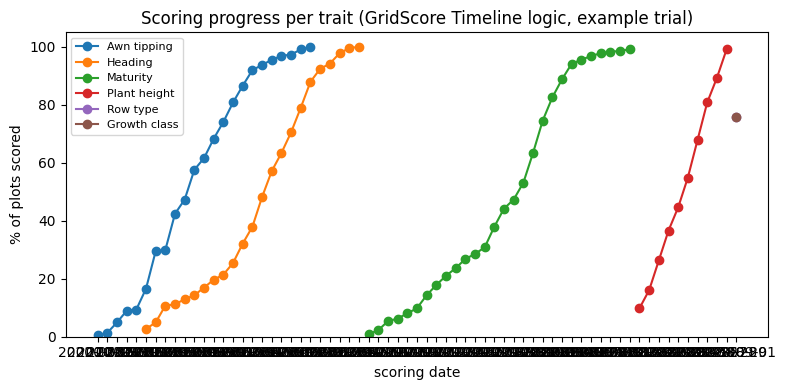

In [ ]:
from collections import defaultdict

n_plots = ROWS * COLS
fig, ax = plt.subplots(figsize=(8, 4))
for i, t in enumerate(TRAITS):
    per_date = defaultdict(int)
    for y in range(ROWS):
        for x in range(COLS):
            v, d = cells[y][x]['values'][i], cells[y][x]['dates'][i]
            if v is not None and d:
                per_date[d] += 1
    if not per_date:
        continue
    dates_sorted = sorted(per_date)
    cumulative, running = [], 0
    for d in dates_sorted:                     # cumulative sum, as in Timeline.vue
        running += per_date[d]
        cumulative.append(running / n_plots * 100)
    ax.plot(dates_sorted, cumulative, marker='o', label=t['name'])
ax.set_xlabel('scoring date'); ax.set_ylabel('% of plots scored')
ax.set_ylim(0, 105); ax.legend(fontsize=8)
ax.set_title('Scoring progress per trait (GridScore Timeline logic, example trial)')
plt.tight_layout(); plt.show()

## Visualization 2 — trait heatmap on the field plan (app: Heatmap view)

The Heatmap view (`src/views/Heatmap.vue`) renders trait values over the field grid (x = column, y = row). For numeric traits whose range spans zero it uses a two-color scale joined at zero; otherwise a light-to-trait-color linear scale. We mirror both cases with a matplotlib two-point colormap. / **日本語:** Heatmapビューと同じグリッド描画（x=列, y=行）を再現します。0をまたぐ場合は0中心の2色スケールを使用します。

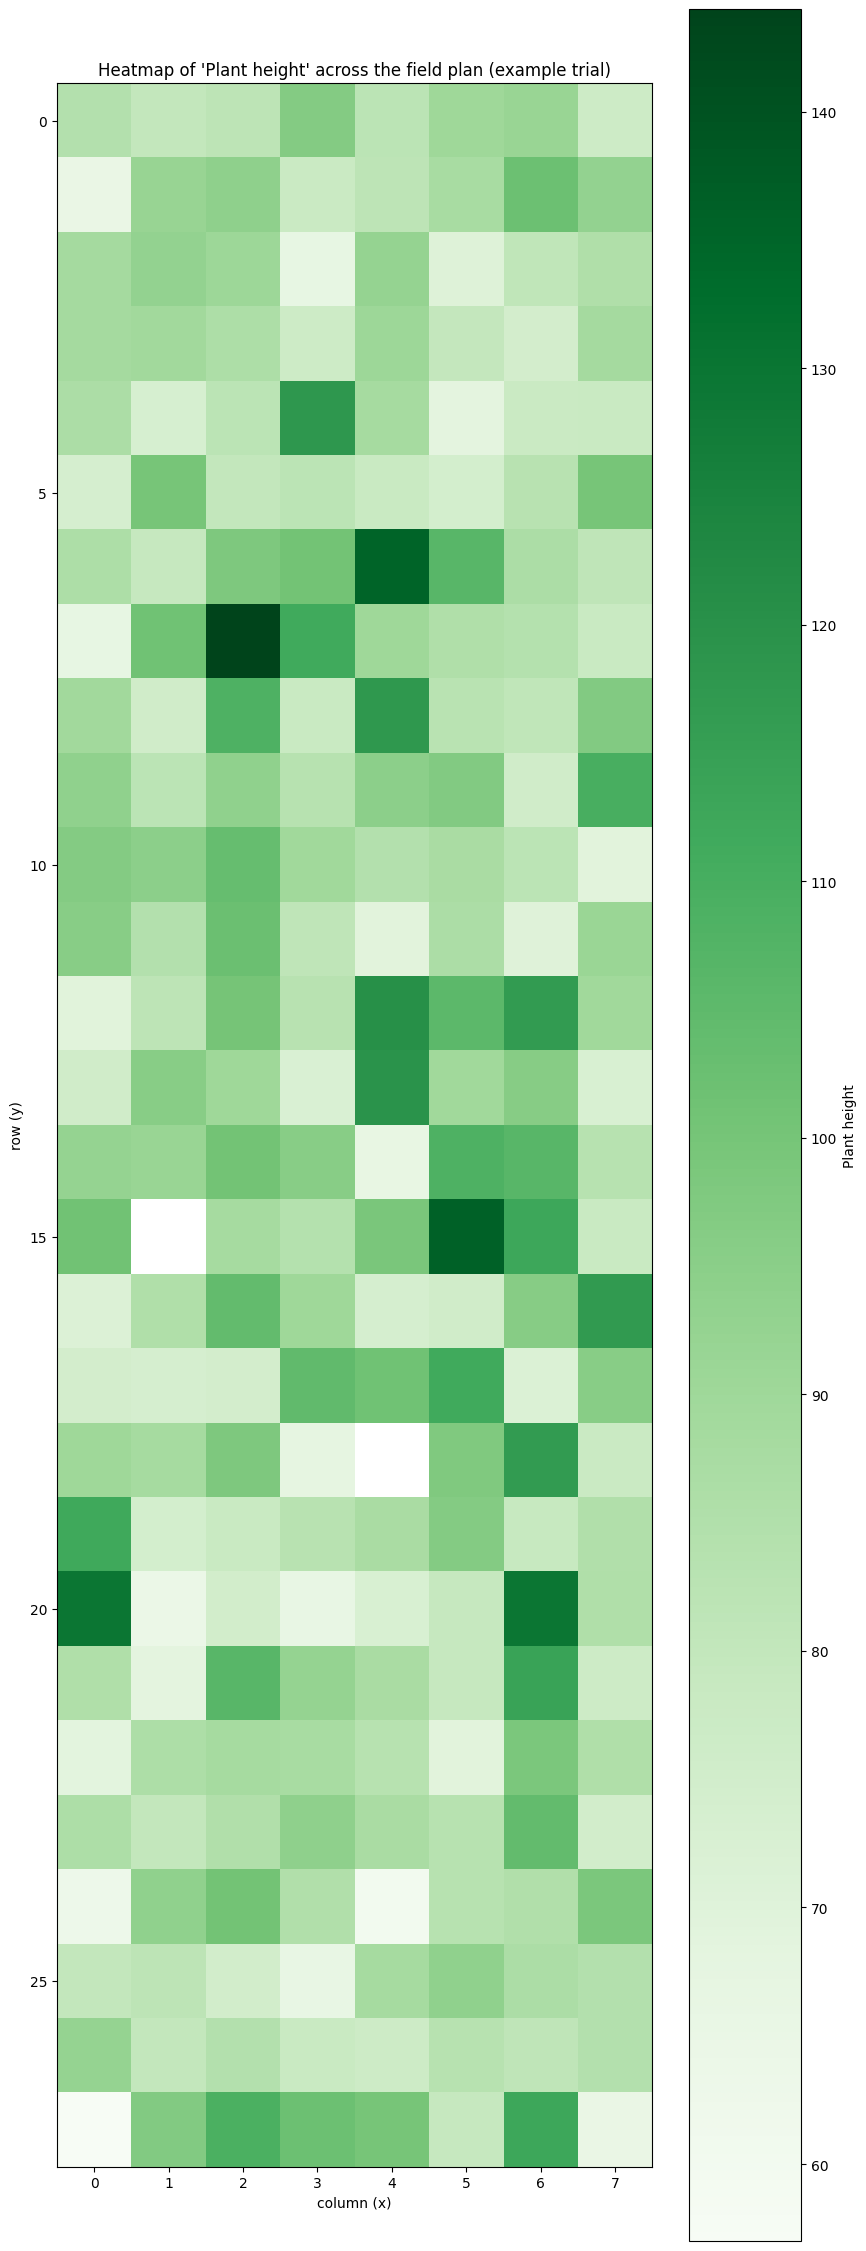

'Plant height': n=222 min=57.0 max=144.0 mean=88.185


In [ ]:
import matplotlib.colors as mcolors
import numpy as np

trait_idx = num_idx
T = TRAITS[trait_idx]
def as_float(v):
    """Numeric coercion: the example trial stores some numeric entries as strings."""
    if v is None or v == '':
        return None
    try:
        return float(v)
    except (TypeError, ValueError):
        return None
grid = [[as_float(cells[y][x]['values'][trait_idx]) for x in range(COLS)] for y in range(ROWS)]
flat = [v for row in grid for v in row if v is not None]
assert flat, 'example trait has no scored values'
fig, ax = plt.subplots(figsize=(1.2 * COLS, 1.2 * ROWS))
lo, hi_v = min(flat), max(flat)
if lo < 0 < hi_v:   # zero-centered two-color scale, as in Heatmap.vue L254-263
    z = -lo / (hi_v - lo)
    cmap = mcolors.LinearSegmentedColormap.from_list('gridscore', ['#1f77b4', '#dddddd', '#d62728'], [0, z, 1])
    norm = mcolors.Normalize(lo, hi_v)
else:
    cmap, norm = 'Greens', mcolors.Normalize(lo, hi_v)
im = ax.imshow(np.ma.masked_invalid(np.array([[np.nan if v is None else v for v in row] for row in grid], dtype=float)), cmap=cmap, norm=norm)
ax.set_xlabel('column (x)'); ax.set_ylabel('row (y)')
ax.set_title(f"Heatmap of '{T['name']}' across the field plan (example trial)")
plt.colorbar(im, ax=ax, label=T['name']); plt.show()

# Numeric summary of the same values (small inspectable table)
vals = [v for y in range(ROWS) for x in range(COLS) if (v := as_float(cells[y][x]['values'][trait_idx])) is not None]
print(f"'{T['name']}': n={len(vals)} min={min(vals)} max={max(vals)} mean={sum(vals)/len(vals):.3f}")

## Visualization 3 — per-trait statistics (app: Stats view)

The Stats view (`src/views/Stats.vue`) draws a **box plot** for int/float/date traits (all observations, with points shown) and a **bar chart of category counts** for categorical/text traits. We reproduce both chart types for the example trial's traits. / **日本語:** Statsビューと同じく、数値・日付形質は箱ひげ図、カテゴリ形質は度数バー図を描きます。

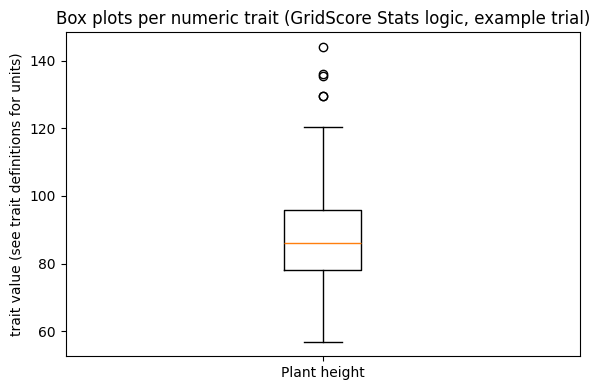

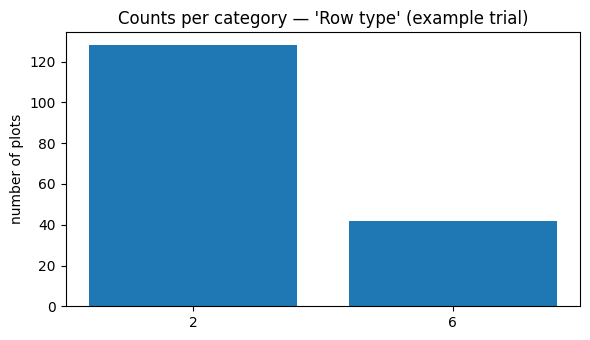

numeric traits plotted: ['Plant height'] | categorical plotted: ['Row type', 'Growth class']


In [ ]:
def trait_values(i):
    vals = []
    for y in range(ROWS):
        for x in range(COLS):
            v = cells[y][x]['values'][i]
            if v is None or v == '':
                continue
            if TRAITS[i]['type'] in ('int', 'float'):   # example trial stores some numerics as strings
                try:
                    v = float(v)
                except (TypeError, ValueError):
                    continue
            vals.append(v)
    return vals

numeric = [i for i, t in enumerate(TRAITS) if t['type'] in ('int', 'float') and trait_values(i)]
if numeric:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot([trait_values(i) for i in numeric], tick_labels=[TRAITS[i]['name'] for i in numeric], showfliers=True)
    ax.set_ylabel('trait value (see trait definitions for units)')
    ax.set_title('Box plots per numeric trait (GridScore Stats logic, example trial)')
    plt.tight_layout(); plt.show()

categorical = [i for i, t in enumerate(TRAITS) if t['type'] == 'categorical' and trait_values(i)]
if categorical:
    i = categorical[0]
    cats = TRAITS[i].get('restrictions', {}).get('categories') or sorted(set(trait_values(i)))
    counts = {k: trait_values(i).count(k) for k in cats}
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(counts.keys(), counts.values())
    ax.set_ylabel('number of plots'); ax.set_title(f"Counts per category — '{TRAITS[i]['name']}' (example trial)")
    plt.tight_layout(); plt.show()
print('numeric traits plotted:', [TRAITS[i]['name'] for i in numeric], '| categorical plotted:', [TRAITS[i]['name'] for i in categorical])

## Tab-delimited export (app: Export view)

`src/views/Export.vue` (L324–410) writes rows in **row-major order** (`y` rows, then `x` columns) with the exact header `Line/Trait<TAB>Rep<TAB><trait names…><TAB>Lat<TAB>Lng<TAB>Elv<TAB>Comment`, skipping cells that have no data. We reproduce that writer byte-faithfully, show the first lines, and save `gridscore_export.tsv` in the Colab workspace (downloadable via the Files panel). / **日本語:** Exportビューと同一書式のタブ区切りエクスポートを再現し、`gridscore_export.tsv` として保存します。

In [ ]:
def export_data_text(cells, traits):
    """Port of the `text` computed property in src/views/Export.vue (L356-410)."""
    result = f"Line/Trait\tRep\t{chr(9).join(t['name'] for t in traits)}\tLat\tLng\tElv\tComment"
    for y in range(ROWS):                       # rows first, then columns — as in the app
        for x in range(COLS):
            cell = cells[y][x]
            data = cell['values']
            if cell['comment'] or (data and not all(c is None or c == '' for c in data)):
                result += '\n' + str(cell['name'])
                result += '\t' + (str(cell['rep']) if cell['rep'] else '')
                result += '\t' + chr(9).join('' if v is None else str(v) for v in data)
                geo = cell['geolocation']
                if geo:
                    result += '\t' + str(geo.get('lat') or '') + '\t' + str(geo.get('lng') or '') + '\t' + str(geo.get('elv') or '')
                else:
                    result += '\t\t\t'
                result += '\t' + (cell['comment'].replace('\n', ' ') if cell['comment'] else '')
    return result

text = export_data_text(cells, TRAITS)
lines = text.split('\n')
print(f'{len(lines) - 1} data rows (+1 header)'); print('\n'.join(lines[:4])); print('…')
open('gridscore_export.tsv', 'w').write(text)
print('saved gridscore_export.tsv,', len(text), 'chars')

224 data rows (+1 header)
Line/Trait	Rep	Awn tipping	Heading	Maturity	Plant height	Row type	Growth class	Lat	Lng	Elv	Comment
Heris	2	2020-06-13	2020-06-19	2020-08-01	84.5	2	Spring	56.4842586	-3.1380437	205.11965514533225	
Dialog	2	2020-06-07	2020-06-16	2020-08-06	80	2	Spring	56.4845815	-3.1381493	205.46555778756735	
Zenit	1	2020-06-15	2020-06-22	2020-08-03	81.5			56.4841559	-3.138647	196.7763286046684	
…
saved gridscore_export.tsv, 21335 chars


## GUI-action → code mapping and limitations

| GridScore GUI action (paper / app) | This notebook | Source (pinned commit `7b9807a…`) |
|---|---|---|
| Trial setup form (name, rows × cols, traits, germplasm grid) | `barley-trial.json` loaded into `data[y][x]` cells | `src/views/Setup.vue` L250–272 |
| Guided mode, 8 navigation orders | `guide_order_next` / `guide_cell_sequence` (serpentine + U-turns) | `src/mixin/types.js` L73–310 |
| Value validation on entry (categories, min/max, integer) | `check_trait_value` | `src/components/DataPointEntry.vue` L582–616 |
| Timeline: % plots scored over time | cumulative counts ÷ plots × 100, line plot | `src/views/Timeline.vue` |
| Heatmap of trait over field plan | grid image, zero-centered 2-color scale | `src/views/Heatmap.vue` L254–276 |
| Stats: box plot / category bar chart | matplotlib box/bar equivalents | `src/views/Stats.vue` |
| Export tab-delimited text | byte-faithful `export_data_text` | `src/views/Export.vue` L356–410 |
| Voice feedback, barcode scan, camera, GPS capture, QR share, BrAPI, georeferencing projection, server sync | **not reproduced (GUI/device-only)** | paper Implementation & Results |

## Interpretation, validation record, references

- **What this validates:** the app's core data pipeline — trial structure, guided-walk order, trait validation, the three visualization computations, and the export format — executed end-to-end on the authors' bundled example trial on CPU. The example's scored values, dates and germplasm are the authors' own demo data; plots are generated here from those data and are not author figures.
- **What this does not validate:** GUI interaction, device sensors, server sync, BrAPI, and the paper's qualitative feature comparison (Table 1). The paper reports no quantitative accuracy metrics, so there are no published numbers to compare against.
- Sources: paper DOI [10.1186/s12859-022-04755-2](https://doi.org/10.1186/s12859-022-04755-2) (BMC Bioinformatics 23:214, 2022; open access CC BY); code `cropgeeks/gridscore` @ `7b9807a3316c42bcda5a5f9898a42a0859e3d9d8`, Apache-2.0; example data `src/assets/data/barley-trial.json` at the same commit. / **参考文献:** 論文DOIとコードのpinnedコミットは冒頭のとおりです。
- Reproduced headlessly from JavaScript under Apache-2.0; this AI-assisted port is not author-endorsed (see notice at the top).